# **Εργασία 2**

**Καθηγητής:**  Θεοδωρακόπουλος Ηλίας

**Φοιτητής:** Ιατρού Κωνσταντίνος 58071

# **Άσκηση 2**

Έστω δυο κατηγορίες ω1 και ω2 , των οποίων τα δείγματα σε 2-διαστάσεις  ακολουθούν κατανομές που περιγράφονται από τις ακόλουθες πυκνότητες πιθανότητας:

p(x|ω1) = Ν(μ1,Σ1) και p(x|ω2) = Ν(μ2,Σ2),

με μ1= [2, 2], Σ1 = [[2, -0.5],[-0.5, 1]] και μ2 = [-8, 2], Σ2 = [[1, 0.5],[0.5, 1]]

Γράψτε κώδικα ώστε να παράξετε 150 τυχαία δείγματα από καθεμία από αυτές τις κατηγορίες και απεικονίστε τα δείγματα κατάλληλα ώστε να διακρίνονται οι κλάσεις.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from sklearn.svm import SVC

Αρχικά εισάγω τις βιβλιοθήκες και τα modules που θα χρειαστούν για την υλοποίηση της άσκησης.

In [2]:
mu1 = np.array([2,2])
sigma1 = np.array([[2, -0.5], [-0.5, 1]])

mu2 = np.array([-8,2])
sigma2 = np.array([[1, 0.5], [0.5, 1]])

Ορίζω τα μ1, Σ1 και μ2, Σ2 με την συγκεκριμένη σειρά.

In [3]:
np.random.seed(147)
class1 = np.random.multivariate_normal(mu1, sigma1, size=150)
class2 = np.random.multivariate_normal(mu2, sigma2, size=150)

Παράγω 150 τυχαία δείγματα από κάθεμία από τις κατανομές p(x|w1) και p(x|w2). Το seed ορίστηκε για να παράγει επαναλήψιμα αποτελέσματα.

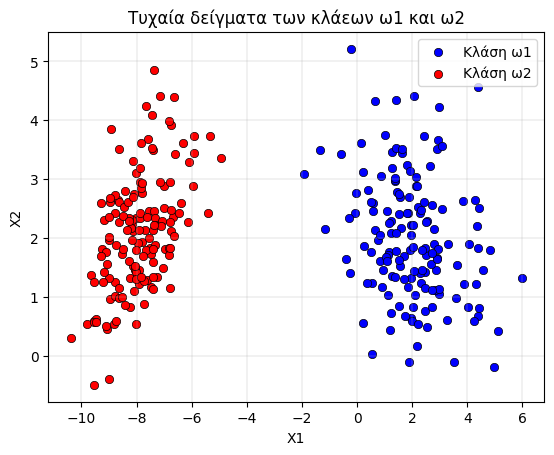

In [4]:
# Απεικονίση των δειγμάτων
plt.grid(linewidth=0.25)
plt.scatter(class1[:, 0], class1[:, 1], label='Κλάση ω1', color='blue', linewidths=.5, edgecolors='k')
plt.scatter(class2[:, 0], class2[:, 1], label='Κλάση ω2', color='red', linewidths=.5, edgecolors='k')
plt.xlabel('X1')
plt.ylabel('X2')
plt.legend()
plt.title('Tυχαία δείγματα των κλάεων ω1 και ω2')
plt.show()

Τυπώνω τα όλα δείγματα πάνω σε διάγραμμα για να τα οπτικοποιήσω πριν προχωρήσω σε ταξινόμηση.

In [5]:
data = np.vstack((class1,class2))
class_labels = np.hstack((np.ones(150), -np.ones(150)))

# Ερώτημα Α

Υλοποιείστε τον αλγόριθμό του Batch Perceptron και με αυτόν υπολογίστε έναν
γραμμικό ταξινομητή για τις κλάσεις αυτές. Απεικονίστε την επιφάνεια απόφασης
που προέκυψε επάνω στο προηγούμενο γράφημα.

In [6]:
def batch_perceptron(X, y, learning_rate=0.01, iterations=100):
    # Προσθέστε τον bias term στο X (μία στήλη με ασσούς)
    X = np.hstack((np.ones((X.shape[0], 1)), X))

    # Αρχικοποιήστε τα βάρη
    weights = np.zeros(X.shape[1])

    # Εκπαίδευση μέσω Batch Perceptron Algorithm

    for iter in range(iterations):
        error_sum = 0
        for i, x in enumerate(X):
            if (np.dot(x, weights) * y[i]) <= 0:
                weights += learning_rate * x * y[i]
                error_sum += (np.dot(x, weights) * y[i])
        if error_sum == 0:
            break

    return weights

Αρχικά υλοποιώ τον αλγόριθμο Batch Perceptron στην συνάρτηση batch_perceptron(X,y,learning_rate, epochs)
Στην υλοποίηση διαφοροποιήσα την συνθήκη τερματισμού σε συγκεκριμένο αριθμό επαναλήψεων και ανάλογα με τα αποτελέσματα μπορώ να τον τροποποιήσω αυξάνοντας ή μειώνοντας τον ανάλογα με τις απαιτήσεις και τον χρόνο που έχω στην διάθεση μου για την αναμονή των αποτελεσμάτων. Η τιμή 100 επιλέχθηκε μετά από μερικές δοκιμές, βέβαια αν το σφάλμα μηδενίσει πριν τις 100 επαναλήψεις θα σταματάει η συνάρτηση και θα επιστρέφει τα αποτελέσματα.

Αρχικά τροποποιώ τα δεδομένα ώστε να προσθέσω το bias (στήλη με την τιμή 1 παντού) και αρχικοποιώ τον πίνακα με τα βάρη στην τιμή 0 (θα είναι πίνακας γραμμής με στοιχεία όσα τα στοιχεία του τροποποιημένου πίνακα δεδομένων, δηλαδή στο δικό μας παράδειγμα 1+2=3).

Στην συνέχεια έχω τον βρόχο που τρέχει τον αλγόριθμο του Batch Perceptron που ορίζεται να τρέξει για όσες επαναλήψεις ζητάει ο χρήστης στις παραμέτρους εισόδου (default=100).
Στην αρχή κάθε επανάληψης το σφάλμα ορίζεται στο 0 και για κάθε δεδομένο Χ (νέος βρόχος) υπολογίζει αν η τιμή np.dot(x, weights) * y[i] είναι μη θετική. Αν ισχύει αυτό σημαίνει ότι ταξινομείται λάθος (ή σωστά αν είναι 0) και συνεπώς υπολογίζεται το σφάλμα για το συγκεκριμένο δεδομένο και προστίθεται στο συνολικό για το συγκεκριμένο iteration του μεγάλου βρόχου. Πριν προστεθεί το σφάλμα για το συγκεκριμένο σημείο στο συνολικό τροποιούμε το βάρος με τον τρόπο που ορίζεται και στην θεωρία:

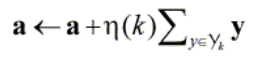

Αν το συνολικό σφάλμα σε όλο το iteration είναι 0 σημαίνει ότι βρέθηκε η λύση και ο αλγόριθμος τερματίζει και επιστρέφει τον πίνακα με τα βάρη.
Αλλιώς ολοκληρώνει όλα τα iterations που δηλώθηκαν και μετά τερματίζει επιστρέφωντας τα βάρη που είχε υπολογίσει μέχρι εκείνη την στιγμή.

In [7]:
# Συνάρτηση για να προβλέψουμε τις κατηγορίες με βάση τα βάρη
def predict(X, weights):
    X = np.hstack((np.ones((X.shape[0], 1)), X))
    return np.sign(np.dot(X, weights))


In [8]:
# Συνάρτηση για να πλοτάρουμε την επιφάνεια απόφασης
def plot_decision_boundary(X, y, weights):
    # Εύρος των τιμών στους άξονες
    x1_min, x1_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    x2_min, x2_max = X[:, 1].min() - 1, X[:, 1].max() + 1

    # Δημιουργία πλέγματος για να κάνουμε προβλέψεις
    xx1, xx2 = np.meshgrid(np.arange(x1_min, x1_max, 0.001),
                            np.arange(x2_min, x2_max, 0.001))

    # Προβλέψεις για κάθε σημείο στο πλέγμα
    Z = predict(np.c_[xx1.ravel(), xx2.ravel()], weights)
    Z = Z.reshape(xx1.shape)

    # Πλοτάρισμα της επιφάνειας απόφασης
    plt.contourf(xx1, xx2, Z, alpha=0.4, cmap=ListedColormap(['r', 'b']))

    # Πλοτάρισμα των δειγμάτων
    plt.scatter(class1[:, 0], class1[:, 1], label='ω1', color='blue', linewidths=.5, edgecolors='black')
    plt.scatter(class2[:, 0], class2[:, 1], label='ω2', color= 'red', linewidths=.5, edgecolors='black')

    plt.xlabel('X1')
    plt.ylabel('X2')
    plt.title('Επίπεδο απόφασης αλγόριθμου Batch Perceptron')
    plt.show()


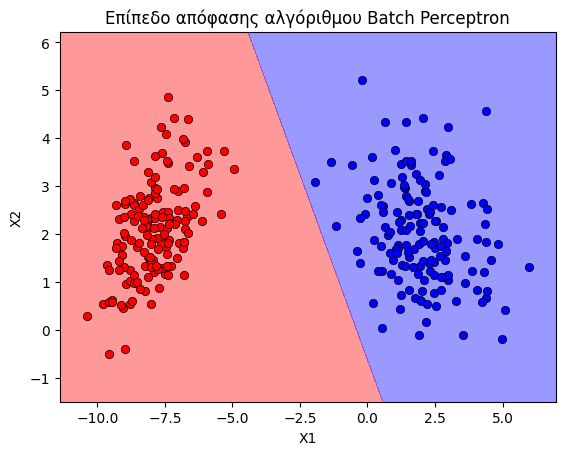

In [9]:

# Υπολογισμός των βαρών με τον Batch Perceptron
weights = batch_perceptron(data, class_labels)

# Πλοτάρισμα της επιφάνειας απόφασης και των δειγμάτων
plot_decision_boundary(data, class_labels, weights)

# Ερώτημα Β

Χρησιμοποιείστε γραμμικό SVM (από κατάλληλη βιβλιοθήκη της επιλογής σας)
για να υπολογίσετε έναν νέο γραμμικό ταξινομητή για τα ίδια δεδομένα.
Απεικονίστε τα δεδομένα, τα support vectors και το επίπεδο απόφασης σε νέο
διάγραμμα

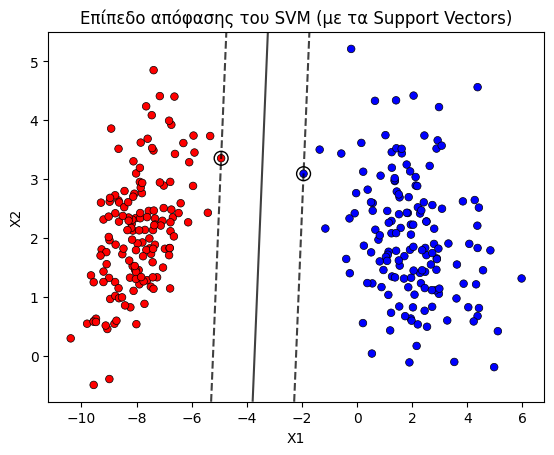

In [10]:
# Εκπαίδευση γραμμικού SVM ταξινομητή
svm = SVC(kernel='linear')
svm.fit(data, class_labels)

# Σχεδίαση των δεδομένων και των support vectors
plt.scatter(data[:, 0], data[:, 1], c=class_labels, s=30, cmap=ListedColormap(['r', 'b']), edgecolors='k', linewidths=0.5)
plt.scatter(svm.support_vectors_[:, 0], svm.support_vectors_[:, 1], s=100, facecolors='none', edgecolors='k', marker='o')

# Σχεδίαση του επιπέδου απόφασης
ax = plt.gca()
xlim = ax.get_xlim()
ylim = ax.get_ylim()

# Δημιουργία grid για να οπτικοποιήσω το επίπεδο απόφασης στην συνέχεια
xx = np.linspace(xlim[0], xlim[1], 100)
yy = np.linspace(ylim[0], ylim[1], 100)
YY, XX = np.meshgrid(yy, xx)
xy = np.vstack([XX.ravel(), YY.ravel()]).T
Z = svm.decision_function(xy).reshape(XX.shape)

# Σχεδίαση των διαχωριστικών επιπέδων και των margins
ax.contour(XX, YY, Z, colors='k', levels=[-1, 0, 1], alpha=0.75, linestyles=['--', '-', '--'])

plt.xlabel('X1')
plt.ylabel('X2')
plt.title('Επίπεδο απόφασης του SVM (με τα Support Vectors)')
plt.show()


Σε αντίθεση με τα προηγούμενα, εδώ δεν δημιουργήθηκε ξεχωριστή συνάρτηση για την υλοποίηση και την απεικόνιση. Απλά έτρεξα τις εντολές γραμμή προς γραμμή.

Αρχικά δημιούργησα ένα αντικείμενο τύπου SVC με το όνομα svm το οποίο είναι στην ουσία ένα αντικείμενο ταξινομητή SVM με γραμμικό kernel.
Αμέσως μετά εκπαίδευσα τον ταξινομήτή με βάση τα δεδομένα που παρήγαγα στην αρχή και τις labels τους (supervized learning).

Στην συνέχεια οποτικοποίησα τα δεδομένα πάνω σε ένα διάγραμμα με τον χρωματισμό και τα οπτικά χαρακτηριστικά της επιθυμίας μου (όπως ακριβώς έκανα και στα υπόλοιπα ερωτήματα) και αμέσως στην επόμενη γραμμή σχεδίασα πάνω στο ίδιο διάγραμμα τα support vectors κυκλώνοντας τα δεδομένα τα οποία χρησιμοποιούνται για support vectors. Στην ουσία είναι τα δεδομένα από κάθε κλάση που είναι πιο κοντά στο επίπεδο απόφασης καθώς αυτά παίζουν καθοριστικό ρόλο για το επίπεδο απόφασης.

Στην συνέχεια παίρνω τα άκρα των διαστημάτων των αξόνων που έχω απεικονίση τα στοιχεία και δημιουργώ ένα grid δεν θα περιγράψω αναλυτικά την δημιουργία του grid γιατί κάτι ανάλογο έγινε και στην προηγούμενη άσκηση.

Στην μεταβλητή Ζ βάζω τις τιμές για να γίνει η απεικόνιση του επιπέδου απόφασης στο διάγραμμα και με την contour (δεν προτιμήθηκε η contourf γιατί δεν μου άρεσε το οπτικό αποτέλεσμα που έδινε) πρόσθεσα πάνω στο διάγραμμα το επίπεδο.

Στο τέλος απλά δίνω την εντολή εμφάνισης του διαγράμματος αφού προσθέσω ονόματα στους άξονες και τίτλο.